# Backtest a trading strategy on `ig_market_data.db`

Loads historical candles for one `epic` / `resolution` from
`data/ig_market_data.db` (produced by `download_ig_prices.ipynb` /
`import_csv_to_db.ipynb`), restricts them to a chosen date window, runs a
strategy through the small backtester in `backtest.py`, and shows the
results: a metrics table (**initial funding -> final funding**), the
round-trip trade list, and price / equity / drawdown charts.

**Engine (`backtest.py`)** - a CFD-style fixed-size position: the account
starts with `INITIAL_FUNDING` (default **20,000 AUD**), one index point is
worth `POINT_VALUE` per contract (default **1.0 AUD/point**), and `SIZE`
contracts are held while long / 0 while flat. Long **or** flat only, fills at
the **next bar's open** after a signal (no look-ahead), a flat `fee_bps` cost
per entry and exit, prices are the bid/ask mid. Teaching-grade, not an
execution simulator.

**Strategy** - the default is `SmaCrossover`: long while the fast simple
moving average of the close is above the slow one, flat otherwise.
`BuyHold` is included as the benchmark. Add your own by subclassing
`backtest.Strategy` and implementing `signal(df)`.

Needs `python-dotenv` (for `config.py`), `pandas`, `matplotlib`.

In [1]:
%pip install -q python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Config, window & strategy

`EPIC` / `RESOLUTION` / `DB_PATH` come from `config.py` (`.env`), same as the
other notebooks. Set `START` / `END` to bound the backtest (either may be
`None`), and pick the strategy + its parameters here.

In [2]:
import sqlite3

import pandas as pd

import backtest
from candle_db import load_candles
from config import Config
from constants.ohlc_fields import OHLCField

cfg = Config.from_env()
EPIC = cfg.epic
RESOLUTION = cfg.resolution
DB_PATH = cfg.db_path

# Backtest window (inclusive). None = use all available history on that side.
START = "2021-01-01"
END = None

# Strategy under test.
strategy = backtest.SmaCrossover(fast=10, slow=30)

# Account model.
INITIAL_FUNDING = 20_000.0  # starting balance, account currency
POINT_VALUE = 1.0           # account-currency P&L per index point, per contract
SIZE = 1.0                  # contracts held while long
CURRENCY = "AUD"
FEE_BPS = 1.0               # cost per entry and per exit, basis points of notional

print(f"{EPIC}  {RESOLUTION}   DB: {DB_PATH}")
print(f"window  : {START or 'earliest'}  ->  {END or 'latest'}")
print(f"strategy: {strategy.name}")
print(f"account : {INITIAL_FUNDING:,.0f} {CURRENCY}   {SIZE:g} contract(s) @ {POINT_VALUE:g} {CURRENCY}/point   fee {FEE_BPS} bps")

IX.D.NASDAQ.IFA.IP  DAY   DB: data\ig_market_data.db
window  : 2021-01-01  ->  latest
strategy: SMA 10/30 crossover
account : 20,000 AUD   1 contract(s) @ 1 AUD/point   fee 1.0 bps


## 2. Load candles from `ig_market_data.db`

`candle_db.load_candles` yields one flat OHLC dict per candle (mid prices);
here they become a `DatetimeIndex`ed DataFrame clipped to the window.

In [3]:
conn = sqlite3.connect(DB_PATH)
df = pd.DataFrame(load_candles(conn, RESOLUTION, epic=EPIC))
conn.close()

assert not df.empty, (
    f"No candles for {EPIC} / {RESOLUTION} in {DB_PATH} - run download_ig_prices.ipynb "
    "or import_csv_to_db.ipynb first."
)

df[OHLCField.SNAPSHOT_TIME_UTC] = pd.to_datetime(
    df[OHLCField.SNAPSHOT_TIME_UTC], format="%Y-%m-%dT%H:%M:%S"
)
df = df.set_index(OHLCField.SNAPSHOT_TIME_UTC).sort_index()
df = df[[OHLCField.OPEN, OHLCField.HIGH, OHLCField.LOW, OHLCField.CLOSE, OHLCField.VOLUME]]

if START:
    df = df[df.index >= pd.Timestamp(START)]
if END:
    df = df[df.index <= pd.Timestamp(END)]

assert len(df) > 50, (
    f"Only {len(df)} bars in the window - widen START/END or download more history."
)
print(f"{len(df)} bars   {df.index[0]:%Y-%m-%d %H:%M}  ->  {df.index[-1]:%Y-%m-%d %H:%M}")
df.head()

1766 bars   2021-01-03 13:00  ->  2026-09-04 14:00


,open,high,low,close,volume
snapshot_time_utc,,,,,
2021-01-03 13:00:00,12908.2,12964.6,12830.5,12957.5,78873
2021-01-04 13:00:00,12956.6,12958.6,12529.7,12689.7,651215
2021-01-05 13:00:00,12689.2,12853.9,12501.6,12599.4,596853
2021-01-06 13:00:00,12600.3,12809.8,12563.3,12724.8,630907
2021-01-07 13:00:00,12725.5,13013.8,12715.1,13001.6,407913


## 3. Run the backtest

`run_backtest` returns a `BacktestResult` (equity curve, trades, stats).
`.summary()` prints the headline metrics; buy & hold over the same window is
shown for comparison.

In [4]:
result = backtest.run_backtest(
    df, strategy,
    initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
    fee_bps=FEE_BPS, currency=CURRENCY,
)
print(result.summary())

strategy           : SMA 10/30 crossover
period             : 2021-01-03 -> 2026-09-04  (1766 bars)
initial funding    : 20,000.00 AUD
final funding      : 31,461.10 AUD
profit / loss      : +11,461.10 AUD  (+57.31%)
buy & hold         : +16,533.00 AUD  (+82.67%)
position size      : 1 @ 1 AUD/point   (~0.65x funding at entry)
CAGR               : +8.32%
ann. volatility    : 10.95%
Sharpe (rf=0)      : 0.79
max drawdown       : -17.01%
time in market     : 62.5%
trades             : 31
win rate           : 45.2%
avg / best / worst : +373.52 / +5,188.30 / -1,236.30 AUD


## 4. Trades

One row per round-trip (entry -> exit). `points` is the price move,
`pnl` is that move in `CURRENCY` (`points * POINT_VALUE * SIZE`), `open =
True` marks a position still held at the end of the window, marked out at the
last mid for accounting.

In [5]:
trades = result.trades.copy()
if not trades.empty:
    trades["return_pct"] = trades["return_pct"].round(2)
trades

,entry_time,exit_time,entry_price,exit_price,points,pnl,return_pct,bars_held,open
0,2021-02-07 13:00:00,2021-02-26 13:00:00,13630.1,12848.5,-781.6,-781.6,-5.73,17,False
1,2021-03-29 13:00:00,2021-05-07 14:00:00,12928.7,13731.3,802.6,802.6,6.21,34,False
2,2021-05-31 14:00:00,2021-09-21 14:00:00,13676.7,15078.6,1401.9,1401.9,10.25,97,False
3,2021-10-21 13:00:00,2021-12-03 13:00:00,15350.9,16020.2,669.3,669.3,4.36,37,False
4,2021-12-30 13:00:00,2022-01-10 13:00:00,16525.9,15381.2,-1144.7,-1144.7,-6.93,9,False
5,2022-03-23 13:00:00,2022-04-17 14:00:00,14535.7,13868.0,-667.7,-667.7,-4.59,20,False
6,2022-06-05 14:00:00,2022-06-15 14:00:00,12569.4,11478.0,-1091.4,-1091.4,-8.68,9,False
7,2022-07-12 14:00:00,2022-08-29 14:00:00,11830.3,12524.1,693.8,693.8,5.86,41,False
8,2022-10-27 13:00:00,2022-11-10 13:00:00,11391.1,10845.7,-545.4,-545.4,-4.79,12,False
9,2022-11-15 13:00:00,2022-12-15 13:00:00,11880.8,11611.2,-269.6,-269.6,-2.27,26,False


## 5. Charts

Price with the moving averages and buy/sell markers, the strategy equity
curve against buy & hold, and the strategy drawdown.

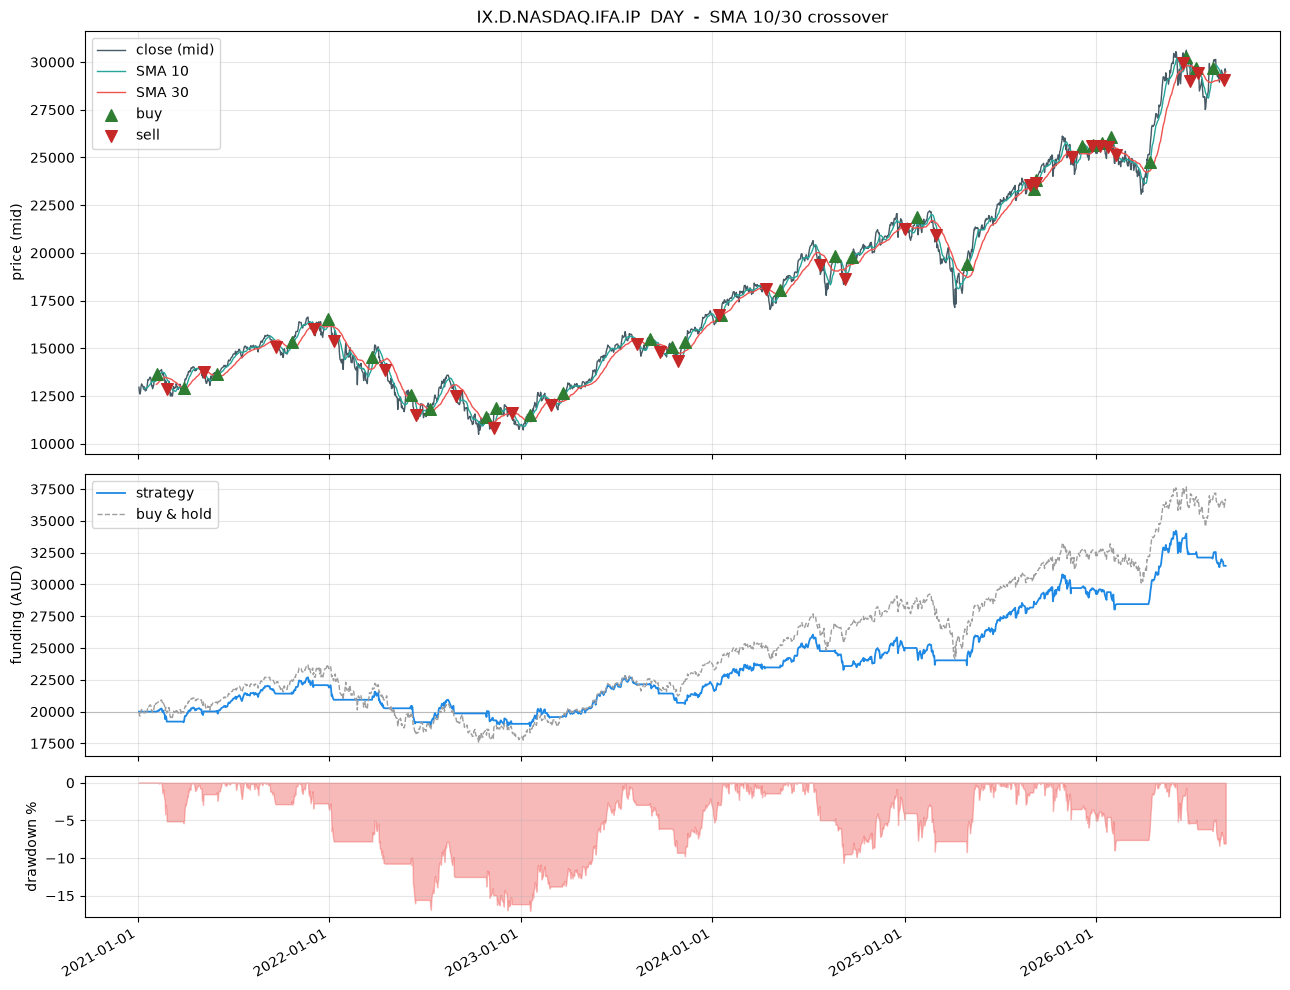

In [6]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

close = df[OHLCField.CLOSE]
eq = result.equity
# buy & hold account value: same funding, same SIZE contracts held throughout
bh = INITIAL_FUNDING + (close - close.iloc[0]) * POINT_VALUE * SIZE
dd = (eq / eq.cummax() - 1) * 100
t = result.trades

fig, (ax_px, ax_eq, ax_dd) = plt.subplots(
    3, 1, sharex=True, figsize=(13, 10),
    gridspec_kw={"height_ratios": [3, 2, 1]},
)

ax_px.plot(close.index, close, color="#455a64", lw=1, label="close (mid)")
if hasattr(strategy, "fast"):
    ax_px.plot(close.index, close.rolling(strategy.fast).mean(), color="#26a69a", lw=1,
               label=f"SMA {strategy.fast}")
    ax_px.plot(close.index, close.rolling(strategy.slow).mean(), color="#ef5350", lw=1,
               label=f"SMA {strategy.slow}")
if not t.empty:
    ax_px.scatter(t["entry_time"], t["entry_price"], marker="^", s=70, color="#2e7d32",
                  zorder=5, label="buy")
    closed = t[~t["open"]]
    ax_px.scatter(closed["exit_time"], closed["exit_price"], marker="v", s=70, color="#c62828",
                  zorder=5, label="sell")
ax_px.set_ylabel("price (mid)")
ax_px.set_title(f"{EPIC}  {RESOLUTION}  -  {strategy.name}")
ax_px.legend(loc="upper left")
ax_px.grid(alpha=0.3)

ax_eq.axhline(INITIAL_FUNDING, color="#bbbbbb", lw=0.8)
ax_eq.plot(eq.index, eq, color="#1e88e5", lw=1.3, label="strategy")
ax_eq.plot(bh.index, bh, color="#9e9e9e", lw=1, ls="--", label="buy & hold")
ax_eq.set_ylabel(f"funding ({CURRENCY})")
ax_eq.legend(loc="upper left")
ax_eq.grid(alpha=0.3)

ax_dd.fill_between(dd.index, dd, 0, color="#ef5350", alpha=0.4)
ax_dd.set_ylabel("drawdown %")
ax_dd.grid(alpha=0.3)

ax_dd.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Compare a few strategies

Same window, same costs - a quick sweep so the numbers above have something
to sit against. Edit the list to taste.

In [7]:
candidates = [
    backtest.BuyHold(),
    backtest.SmaCrossover(5, 20),
    backtest.SmaCrossover(10, 30),
    backtest.SmaCrossover(20, 50),
    backtest.SmaCrossover(50, 100),
]

rows = []
for strat in candidates:
    try:
        s = backtest.run_backtest(
            df, strat,
            initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
            fee_bps=FEE_BPS, currency=CURRENCY,
        ).stats
    except ValueError as exc:  # e.g. slow window longer than the data
        print(f"skip {strat.name}: {exc}")
        continue
    rows.append({
        "strategy": strat.name,
        f"final_funding_{CURRENCY}": round(s["final_funding"], 2),
        f"profit_{CURRENCY}": round(s["profit"], 2),
        "return_%": round(s["total_return_pct"], 2),
        "max_dd_%": round(s["max_drawdown_pct"], 2),
        "sharpe": round(s["sharpe"], 2),
        "exposure_%": round(s["exposure_pct"], 1),
        "trades": s["n_trades"],
    })

pd.DataFrame(rows).set_index("strategy")

,final_funding_AUD,profit_AUD,return_%,max_dd_%,sharpe,exposure_%,trades
strategy,,,,,,,
buy & hold,36532.60,16532.60,82.66,-25.98,0.76,99.9,1
SMA 5/20 crossover,24079.72,4079.72,20.40,-21.96,0.34,60.5,57
SMA 10/30 crossover,31461.10,11461.10,57.31,-17.01,0.79,62.5,31
SMA 20/50 crossover,27571.47,7571.47,37.86,-19.33,0.50,61.6,18
SMA 50/100 crossover,27717.51,7717.51,38.59,-21.22,0.52,68.2,7
